In [7]:
import numpy as np
import pandas as pd


In [17]:
df = pd.read_csv("fitness_with_activity.csv")
print(df.shape)
df.head()

(2216, 13)


,id,age,gender,weight_kg,height_cm,bmi,resting_heart_rate,calorie_intake,body_fat_pct,lean_mass_pct,sleep_hours,workout_minutes,daily_activity_minutes
0,93706.0,18.0,male,66.3,175.7,21.5,82.0,1987.0,22.7,73.552941,10.785714,60.0,32.142857
1,93711.0,56.0,male,62.1,170.6,21.3,62.0,2840.0,22.8,73.632528,7.571429,300.0,42.857143
2,93712.0,18.0,male,58.9,172.8,19.7,68.0,2045.0,16.7,80.344992,7.928571,450.0,514.285714
3,93714.0,54.0,female,87.1,147.8,39.9,90.0,2493.0,42.1,56.261883,7.285714,0.0,0.000000
4,93717.0,22.0,male,74.4,174.1,24.5,60.0,3151.0,20.4,77.390995,8.571429,0.0,30.000000


In [18]:
df["workout_minutes"] = df["workout_minutes"].clip(upper=1500)

In [19]:
df["daily_activity_minutes"] = df["daily_activity_minutes"].clip(upper=720)

In [21]:
df

,id,age,gender,weight_kg,height_cm,bmi,resting_heart_rate,calorie_intake,body_fat_pct,lean_mass_pct,sleep_hours,workout_minutes,daily_activity_minutes,fitness_score
0,93706.0,18.0,male,66.3,175.7,21.5,82.0,1987.0,22.7,73.552941,10.785714,60.0,32.142857,37.7
1,93711.0,56.0,male,62.1,170.6,21.3,62.0,2840.0,22.8,73.632528,7.571429,300.0,42.857143,81.9
2,93712.0,18.0,male,58.9,172.8,19.7,68.0,2045.0,16.7,80.344992,7.928571,450.0,514.285714,87.3
3,93714.0,54.0,female,87.1,147.8,39.9,90.0,2493.0,42.1,56.261883,7.285714,0.0,0.000000,27.2
4,93717.0,22.0,male,74.4,174.1,24.5,60.0,3151.0,20.4,77.390995,8.571429,0.0,30.000000,55.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2211,102923.0,43.0,female,106.1,173.9,35.1,70.0,2330.0,39.6,58.419604,9.000000,0.0,0.000000,35.1
2212,102933.0,24.0,female,50.8,167.9,18.0,84.0,2614.0,23.0,73.461417,10.000000,360.0,42.857143,59.8
2213,102944.0,55.0,male,78.8,163.1,29.6,82.0,1016.0,33.4,64.733376,7.000000,0.0,42.857143,30.3
2214,102949.0,33.0,male,76.9,180.1,23.7,96.0,5412.0,15.5,82.356307,6.500000,0.0,428.571429,48.7


In [24]:
df

,id,age,gender,weight_kg,height_cm,bmi,resting_heart_rate,calorie_intake,body_fat_pct,lean_mass_pct,sleep_hours,workout_minutes,daily_activity_minutes,fitness_score
0,93706.0,18.0,male,66.3,175.7,21.5,82.0,1987.0,22.7,73.552941,10.785714,60.0,32.142857,37.7
1,93711.0,56.0,male,62.1,170.6,21.3,62.0,2840.0,22.8,73.632528,7.571429,300.0,42.857143,81.9
2,93712.0,18.0,male,58.9,172.8,19.7,68.0,2045.0,16.7,80.344992,7.928571,450.0,514.285714,87.3
3,93714.0,54.0,female,87.1,147.8,39.9,90.0,2493.0,42.1,56.261883,7.285714,0.0,0.000000,27.2
4,93717.0,22.0,male,74.4,174.1,24.5,60.0,3151.0,20.4,77.390995,8.571429,0.0,30.000000,55.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2211,102923.0,43.0,female,106.1,173.9,35.1,70.0,2330.0,39.6,58.419604,9.000000,0.0,0.000000,35.1
2212,102933.0,24.0,female,50.8,167.9,18.0,84.0,2614.0,23.0,73.461417,10.000000,360.0,42.857143,59.8
2213,102944.0,55.0,male,78.8,163.1,29.6,82.0,1016.0,33.4,64.733376,7.000000,0.0,42.857143,30.3
2214,102949.0,33.0,male,76.9,180.1,23.7,96.0,5412.0,15.5,82.356307,6.500000,0.0,428.571429,48.7


In [25]:
import numpy as np

def score(value, ideal, scale, floor=15):
    """100 at the ideal value, decreasing gradually — never drops below `floor`."""
    return np.clip(100 - abs(value - ideal) / scale * 100, floor, 100)

def compute_fitness_score(df):
    age = df["age"]
    is_male = df["gender"] == "male"

    workout_score  = np.clip(df["workout_minutes"] / 180 * 100, 15, 100)
    activity_score = np.clip(df["daily_activity_minutes"] / 45 * 100, 15, 100)

    bf_ideal = np.where(is_male, 15, 23) + np.clip(age - 30, 0, None) * 0.1
    body_fat_score = score(df["body_fat_pct"], bf_ideal, scale=20)

    lean_ideal = np.where(is_male, 78, 62) - np.clip(age - 30, 0, None) * 0.15
    lean_score = score(df["lean_mass_pct"], lean_ideal, scale=25)

    sleep_score = score(df["sleep_hours"], 8, scale=4.5)

    calorie_ideal = np.where(is_male, 2500, 2000) - np.clip(age - 30, 0, None) * 5
    calorie_score = score(df["calorie_intake"], calorie_ideal, scale=1000)

    hr_ideal = 60 + np.clip(age - 30, 0, None) * 0.05
    hr_score = score(df["resting_heart_rate"], hr_ideal, scale=35)

    df["fitness_score"] = (
        0.20 * workout_score + 0.15 * activity_score + 0.15 * body_fat_score
        + 0.15 * lean_score + 0.15 * sleep_score + 0.10 * calorie_score + 0.10 * hr_score
    ).round(1)
    return df

df = compute_fitness_score(df)
df["fitness_score"].describe()

count    2216.000000
mean       58.762951
std        13.721359
min        19.000000
25%        48.100000
50%        58.500000
75%        68.900000
max        94.600000
Name: fitness_score, dtype: float64

In [27]:
df.to_csv("fitness_scored.csv", index=False)

In [28]:
df = pd.read_csv("fitness_scored.csv")

In [29]:
df

,id,age,gender,weight_kg,height_cm,bmi,resting_heart_rate,calorie_intake,body_fat_pct,lean_mass_pct,sleep_hours,workout_minutes,daily_activity_minutes,fitness_score
0,93706.0,18.0,male,66.3,175.7,21.5,82.0,1987.0,22.7,73.552941,10.785714,60.0,32.142857,53.2
1,93711.0,56.0,male,62.1,170.6,21.3,62.0,2840.0,22.8,73.632528,7.571429,300.0,42.857143,88.8
2,93712.0,18.0,male,58.9,172.8,19.7,68.0,2045.0,16.7,80.344992,7.928571,450.0,514.285714,90.2
3,93714.0,54.0,female,87.1,147.8,39.9,90.0,2493.0,42.1,56.261883,7.285714,0.0,0.000000,39.7
4,93717.0,22.0,male,74.4,174.1,24.5,60.0,3151.0,20.4,77.390995,8.571429,0.0,30.000000,65.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2211,102923.0,43.0,female,106.1,173.9,35.1,70.0,2330.0,39.6,58.419604,9.000000,0.0,0.000000,47.8
2212,102933.0,24.0,female,50.8,167.9,18.0,84.0,2614.0,23.0,73.461417,10.000000,360.0,42.857143,72.7
2213,102944.0,55.0,male,78.8,163.1,29.6,82.0,1016.0,33.4,64.733376,7.000000,0.0,42.857143,46.9
2214,102949.0,33.0,male,76.9,180.1,23.7,96.0,5412.0,15.5,82.356307,6.500000,0.0,428.571429,58.0


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

df = pd.read_csv("fitness_scored.csv")

df["gender"] = df["gender"].map({"male": 1, "female": 0})

feature_cols = [
    "age", "gender", "weight_kg", "height_cm",
    "resting_heart_rate", "calorie_intake", "body_fat_pct",
    "lean_mass_pct", "sleep_hours", "workout_minutes", "daily_activity_minutes",
]

X = df[feature_cols]
y = df["fitness_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

model.fit(X_train, y_train)

preds = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, preds))
print("R²:", r2_score(y_test, preds))

MAE: 1.441768450350375
R²: 0.9837345662790343


In [31]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
}

search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=75,
    scoring="neg_mean_absolute_error",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV MAE:", -search.best_score_)

best_model = search.best_estimator_
preds = best_model.predict(X_test)

from sklearn.metrics import mean_absolute_error, r2_score
print("Test MAE:", mean_absolute_error(y_test, preds))
print("Test R²:", r2_score(y_test, preds))

Fitting 5 folds for each of 75 candidates, totalling 375 fits
Best params: {'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.6}
Best CV MAE: 1.3062789295937496
Test MAE: 1.1974372941094473
Test R²: 0.9890824793195699


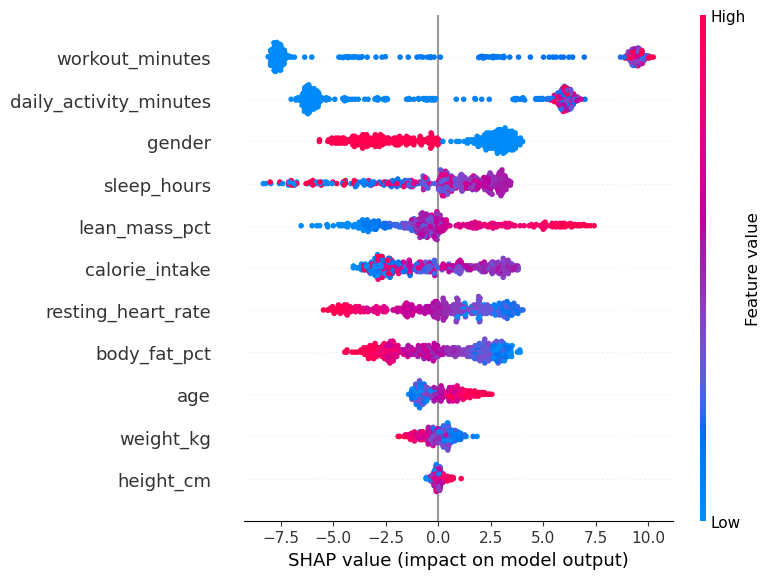

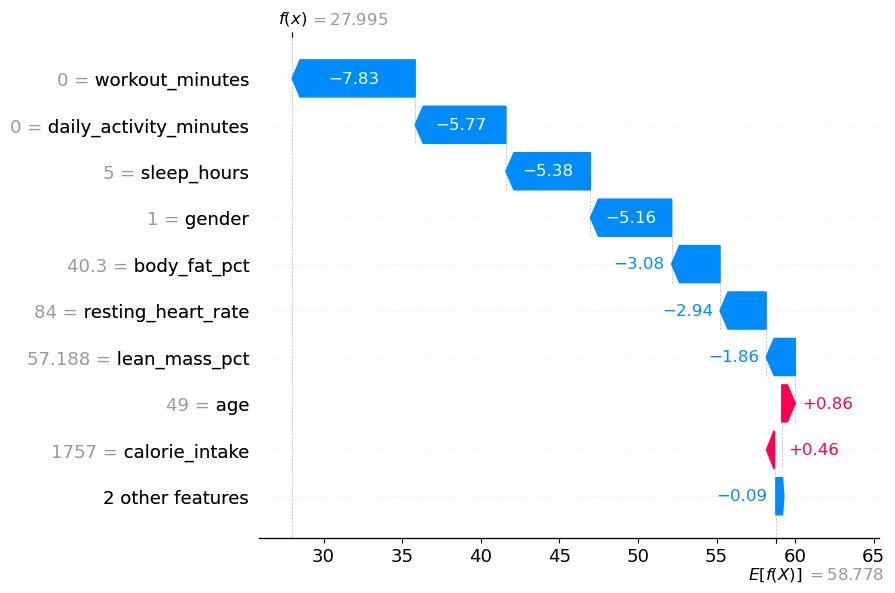

In [32]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

shap.plots.waterfall(shap_values[0])